## Insights and Recommendations

This notebook analyzes the sentiment and thematic analysis results to derive actionable insights and recommendations for the three Ethiopian banks.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the sentiment and theme analysis data
sentiment_data = pd.read_csv('../data/sentiment_theme_analysis.csv')
theme_summary = pd.read_csv('../data/theme_summary.csv')
print(f"Loaded {len(sentiment_data)} reviews")
print(f"Theme summary has {len(theme_summary)} rows")


Loaded 1031 reviews
Theme summary has 21 rows


## Overall Sentiment Analysis by Bank


In [3]:
# Calculate overall sentiment statistics by bank
bank_sentiment = sentiment_data.groupby('bank')['primary_sentiment'].value_counts(normalize=True).unstack().fillna(0) * 100
bank_rating = sentiment_data.groupby('bank')['rating'].mean()
# Create a combined dataframe
bank_stats = pd.DataFrame({
    'Positive %': bank_sentiment['positive'],
    'Neutral %': bank_sentiment['neutral'],
    'Negative %': bank_sentiment['negative'],
    'Avg Rating': bank_rating
}).round(2)
print("Overall Bank Sentiment Statistics:")
display(bank_stats)

Overall Bank Sentiment Statistics:


,Positive %,Neutral %,Negative %,Avg Rating
bank,,,,
BOA,39.24,35.47,25.29,2.83
CBE,61.06,30.53,8.41,4.07
Dashen,72.68,20.49,6.83,4.38


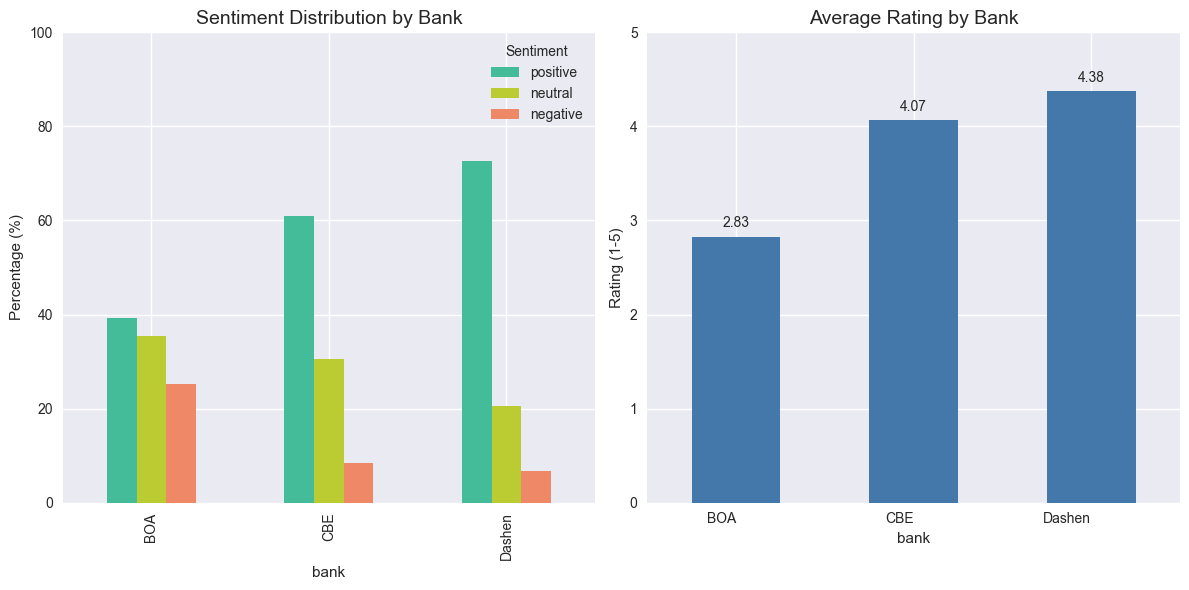

In [10]:

# Visualize sentiment distribution
plt.figure(figsize=(12, 6))
# Plot sentiment percentages
ax1 = plt.subplot(1, 2, 1)
bank_sentiment[['positive', 'neutral', 'negative']].plot(kind='bar', stacked=False, ax=ax1, 
                                                      color=['#44BB99', '#BBCC33', '#EE8866'])
ax1.set_title('Sentiment Distribution by Bank', fontsize=14)
ax1.set_ylabel('Percentage (%)')
ax1.set_ylim(0, 100)
ax1.legend(title='Sentiment')
# Plot average ratings
ax2 = plt.subplot(1, 2, 2)
bank_rating.plot(kind='bar', ax=ax2, color='#4477AA')
ax2.set_title('Average Rating by Bank', fontsize=14)

ax2.set_ylabel('Rating (1-5)')
ax2.set_ylim(0, 5)
for i, v in enumerate(bank_rating):
    ax2.text(i, v + 0.1, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.savefig('bank_sentiment_comparison.png', dpi=300, bbox_inches='tight')
plt.xticks(rotation=0, ha='right')
plt.show()